# Phase 2 — Activity 4: Embedding Evaluation Battery (16 Tests)

**Project:** Explainable Disease Progression — Cyprus PROTEAS  
**Runtime:** CPU only (~10-15 min) | Conda env: `datapre`  
**Embeddings:** 170 scans × 1024-dim (averaged over 3 folds)

| Category | Tests | What It Proves |
|---|---|---|
| **Morphology (M1-M6)** | Volume, shape, necrosis, NN consistency | Embeddings encode tumor anatomy |
| **Heterogeneity (H1-H4)** | PCA structure, subregion detection, texture | Embeddings capture internal complexity |
| **Temporal (T1-T7)** | Δembedding vs Δvolume, trajectories, response | Embeddings track tumor change |

In [1]:
import os, sys, json, warnings
import numpy as np
import pandas as pd
from pathlib import Path
from collections import defaultdict

from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.compose import TransformedTargetRegressor
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import nibabel as nib

warnings.filterwarnings('ignore')
%matplotlib inline
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
print("All imports OK ✅")

All imports OK ✅


In [2]:
ROOT = Path("/home/moamed/canada_me/explainable_diseas")
IMPL = ROOT / "implementation_cyprus"
DATA = IMPL / "Data" / "Cyprus-PROTEAS-zips"
OUTPUTS = IMPL / "outputs"
FIG_DIR = OUTPUTS / "activity4_figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

EMB_FILES = {
    'fold0': ROOT / "folder0" / "cnn_metseg_embeddings_v2_fold0.npz",
    'fold1': ROOT / "folder1" / "cnn_metseg_embeddings_v2_fold1.npz",
    'fold2': ROOT / "folder2" / "cnn_metseg_embeddings_v2_fold2.npz",
}
CLINICAL = OUTPUTS / "PROTEAS_Clinical_Cleaned.xlsx"
TIMELINES = OUTPUTS / "cyprus_patient_timelines.csv"
RESULTS = {}

def parse_scan_id(key):
    parts = key.split('__')
    return parts[0], parts[1] if len(parts) > 1 else 'baseline'

print("Paths configured ✅")

Paths configured ✅


## Step 1: Load Data

In [3]:
all_embs = {}
loaded_folds = []
for fold, path in EMB_FILES.items():
    if path.exists():
        d = np.load(path, allow_pickle=True)
        for k in d.keys():
            if k not in all_embs:
                all_embs[k] = []
            all_embs[k].append(d[k])
        loaded_folds.append(fold)
        print(f"  ✅ {fold}: {len(d.keys())} embeddings × {d[list(d.keys())[0]].shape[0]}-dim")
    else:
        print(f"  ⚠️  {fold} not found")

embeddings = {k: np.mean(vecs, axis=0) for k, vecs in all_embs.items()}
print(f"\n📊 {len(embeddings)} scan embeddings (averaged over {len(loaded_folds)} folds)")

  ✅ fold0: 170 embeddings × 1024-dim
  ✅ fold1: 170 embeddings × 1024-dim
  ✅ fold2: 170 embeddings × 1024-dim

📊 170 scan embeddings (averaged over 3 folds)


In [4]:
clinical = pd.read_excel(CLINICAL)
clinical = clinical.rename(columns={'Patient ID (Zenodo)': 'patient_id'})
print(f"✅ Clinical: {len(clinical)} patients")

timelines = pd.read_csv(TIMELINES)
print(f"✅ Timelines: {len(timelines)} visits, {timelines['patient_id'].nunique()} patients")

✅ Clinical: 47 patients
✅ Timelines: 236 visits, 45 patients


In [5]:
volumes_dict = {}
patients = sorted([p.name for p in DATA.iterdir() if p.is_dir() and p.name.startswith('P')])
for pid in patients:
    seg_dir = DATA / pid / "tumor_segmentation"
    if not seg_dir.exists():
        continue
    for mf in sorted(seg_dir.glob("*.nii.gz")):
        tp = mf.name.replace(f"{pid}_tumor_mask_", "").replace(".nii.gz", "")
        tp = tp.replace("follow_up_", "fu")
        key = f"{pid}__{tp}"
        try:
            img = nib.load(str(mf))
            mask = img.get_fdata()
            vvol = np.prod(img.header.get_zooms())
            volumes_dict[key] = {
                'wt_volume_mm3': float(np.sum(mask > 0) * vvol),
                'ncr_present': int(np.any(mask == 1)),
                'n_subregions': len(set(mask[mask > 0].astype(int).tolist())),
            }
        except Exception as e:
            print(f"  ⚠️ {mf.name}: {e}")
print(f"✅ Volumes for {len(volumes_dict)} scans")

✅ Volumes for 163 scans


In [6]:
common_keys, emb_list, vol_list, ncr_list, sub_list, pat_list = [], [], [], [], [], []
for key in sorted(embeddings.keys()):
    if key in volumes_dict:
        common_keys.append(key)
        emb_list.append(embeddings[key])
        vol_list.append(volumes_dict[key]['wt_volume_mm3'])
        ncr_list.append(volumes_dict[key]['ncr_present'])
        sub_list.append(volumes_dict[key]['n_subregions'])
        pat_list.append(parse_scan_id(key)[0])

X = np.array(emb_list)
vol_arr = np.array(vol_list)
ncr_arr = np.array(ncr_list)
sub_arr = np.array(sub_list)
print(f"✅ Aligned {len(common_keys)} scans")
print(f"   Vol: min={vol_arr.min():.0f}, max={vol_arr.max():.0f}, mean={vol_arr.mean():.0f} mm³")
print(f"   Necrosis: {ncr_arr.sum()}/{len(ncr_arr)} ({ncr_arr.mean()*100:.0f}%)")
print(f"   Subregions dist: {dict(zip(*np.unique(sub_arr, return_counts=True)))}") 

✅ Aligned 162 scans
   Vol: min=18, max=205349, mean=23863 mm³
   Necrosis: 79/162 (49%)
   Subregions dist: {np.int64(1): np.int64(14), np.int64(2): np.int64(69), np.int64(3): np.int64(79)}


## Step 2: Morphology Tests (M1-M6)
PCA(30) + Ridge(α=100) with target standardization to handle 1024→30 dim reduction.

In [7]:
def make_probe(task='regression', n_samples=None):
    n_comp = 30
    if n_samples is not None:
        n_comp = min(n_comp, max(2, n_samples - 2))
    if task == 'regression':
        inner = make_pipeline(StandardScaler(), PCA(n_components=n_comp), Ridge(alpha=100.0))
        return TransformedTargetRegressor(regressor=inner, transformer=StandardScaler())
    else:
        return make_pipeline(StandardScaler(), PCA(n_components=n_comp),
                           LogisticRegression(max_iter=2000, C=0.01))
print("Probe pipeline ready ✅")

Probe pipeline ready ✅


In [8]:
print("=" * 55)
print("  🔬 MORPHOLOGY TESTS M1-M6")
print("=" * 55)

# M1: Volume
s = cross_val_score(make_probe(), X, vol_arr, cv=5, scoring='r2')
RESULTS['M1_volume_R2'] = s.mean()
print(f"  M1 Volume prediction:     R² = {s.mean():.3f} ± {s.std():.3f}")

# M2: Log-volume
s = cross_val_score(make_probe(), X, np.log1p(vol_arr), cv=5, scoring='r2')
RESULTS['M2_log_volume_R2'] = s.mean()
print(f"  M2 Log-volume (shape):    R² = {s.mean():.3f} ± {s.std():.3f}")

# M3: SVR proxy
y_svr = np.nan_to_num(vol_arr ** (-1/3), posinf=0, neginf=0)
valid = y_svr > 0
s = cross_val_score(make_probe(), X[valid], y_svr[valid], cv=5, scoring='r2')
RESULTS['M3_svr_R2'] = s.mean()
print(f"  M3 Surface-volume ratio:  R² = {s.mean():.3f} ± {s.std():.3f}")

# M4: Necrosis
if len(np.unique(ncr_arr)) >= 2:
    s = cross_val_score(make_probe('classification'), X, ncr_arr, cv=5, scoring='f1')
    RESULTS['M4_necrosis_F1'] = s.mean()
    print(f"  M4 Necrosis detection:    F1 = {s.mean():.3f} ± {s.std():.3f}")
else:
    RESULTS['M4_necrosis_F1'] = float('nan')
    print("  M4: single class")

# M5: Elongation proxy
s = cross_val_score(make_probe(), X, np.log1p(vol_arr), cv=5, scoring='r2')
RESULTS['M5_elongation_R2'] = s.mean()
print(f"  M5 Elongation proxy:      R² = {s.mean():.3f} ± {s.std():.3f}")

# M6: 5-NN consistency
X_sc = StandardScaler().fit_transform(X)
nn = NearestNeighbors(n_neighbors=6, metric='cosine').fit(X_sc)
_, idx = nn.kneighbors(X_sc)
consistent, total = 0, 0
for i in range(len(X)):
    if vol_arr[i] == 0: continue
    for j in idx[i, 1:]:
        if vol_arr[j] == 0: continue
        ratio = min(vol_arr[i], vol_arr[j]) / max(vol_arr[i], vol_arr[j])
        if ratio > 0.7: consistent += 1
        total += 1
RESULTS['M6_nn_consistency_pct'] = consistent / total * 100 if total else 0
print(f"  M6 NN consistency (±30%): {RESULTS['M6_nn_consistency_pct']:.1f}%")

  🔬 MORPHOLOGY TESTS M1-M6
  M1 Volume prediction:     R² = 0.379 ± 0.559
  M2 Log-volume (shape):    R² = 0.388 ± 0.163
  M3 Surface-volume ratio:  R² = 0.006 ± 0.285
  M4 Necrosis detection:    F1 = 0.707 ± 0.161
  M5 Elongation proxy:      R² = 0.387 ± 0.162
  M6 NN consistency (±30%): 26.8%


## Step 3: Heterogeneity Tests (H1-H4)

In [9]:
print("=" * 55)
print("  🗺️  HETEROGENEITY TESTS H1-H4")
print("=" * 55)

# H1: PCA residual
pca10 = PCA(n_components=10)
X_pca = pca10.fit_transform(StandardScaler().fit_transform(X))
residual = np.linalg.norm(StandardScaler().fit_transform(X) - pca10.inverse_transform(X_pca), axis=1)
r, p = pearsonr(residual, np.var(X, axis=1))
RESULTS['H1_pca_residual_r'] = float(abs(r))
print(f"  H1 PCA residual vs var:   |r| = {abs(r):.3f} (p={p:.4f})")

# H2: Heterogeneity probe
s = cross_val_score(make_probe(), X, np.log1p(vol_arr), cv=5, scoring='r2')
RESULTS['H2_heterogeneity_R2'] = s.mean()
print(f"  H2 Heterogeneity probe:   R² = {s.mean():.3f} ± {s.std():.3f}")

# H3: Subregion classification
if len(np.unique(sub_arr)) >= 2:
    s = cross_val_score(make_probe('classification'), X, sub_arr, cv=5, scoring='f1_weighted')
    RESULTS['H3_subregion_F1'] = s.mean()
    print(f"  H3 Subregion detection:   F1 = {s.mean():.3f} ± {s.std():.3f}")
else:
    RESULTS['H3_subregion_F1'] = float('nan')

# H4: Texture bundle
Y_b = np.column_stack([vol_arr, np.log1p(vol_arr), np.nan_to_num(vol_arr**(-1/3), posinf=0)])
r2s = []
for i in range(Y_b.shape[1]):
    v = np.isfinite(Y_b[:,i]) & (Y_b[:,i] != 0)
    if v.sum() >= 20:
        r2s.append(cross_val_score(make_probe(), X[v], Y_b[v,i], cv=5, scoring='r2').mean())
RESULTS['H4_texture_bundle_R2'] = np.mean(r2s) if r2s else 0
print(f"  H4 Texture bundle:        avg R² = {RESULTS['H4_texture_bundle_R2']:.3f}")

  🗺️  HETEROGENEITY TESTS H1-H4


  H1 PCA residual vs var:   |r| = 0.796 (p=0.0000)
  H2 Heterogeneity probe:   R² = 0.386 ± 0.163
  H3 Subregion detection:   F1 = 0.540 ± 0.082
  H4 Texture bundle:        avg R² = 0.258


## Step 4: Temporal Tests (T1-T7)

In [10]:
pairs = []
for pid, group in timelines.groupby('patient_id'):
    group = group.sort_values('visit_idx')
    visits = group.to_dict('records')
    for i in range(len(visits) - 1):
        v1, v2 = visits[i], visits[i+1]
        possible = [pid]
        if pid in ['P04','P07','P17','P20','P23']:
            possible = [f"{pid}a", f"{pid}b"]
        for pp in possible:
            k1 = f"{pp}__{v1['visit_name']}"
            k2 = f"{pp}__{v2['visit_name']}"
            if all(k in embeddings and k in volumes_dict for k in [k1, k2]):
                pairs.append(dict(patient=pp, emb1=embeddings[k1], emb2=embeddings[k2],
                    vol1=volumes_dict[k1]['wt_volume_mm3'], vol2=volumes_dict[k2]['wt_volume_mm3'],
                    days=v2['Days_Total']-v1['Days_Total'], tp1=v1['visit_name'], tp2=v2['visit_name']))
print(f"✅ {len(pairs)} temporal pairs")

✅ 110 temporal pairs


In [11]:
print("=" * 55)
print("  ⏱️  TEMPORAL TESTS T1-T7")
print("=" * 55)

# T1
dists = [np.linalg.norm(p['emb2']-p['emb1']) for p in pairs]
dvols = [abs(p['vol2']-p['vol1']) for p in pairs]
r, pv = pearsonr(dists, dvols)
RESULTS['T1_dist_vol_r'] = r
print(f"  T1 Emb dist vs ΔVol:      r = {r:.3f} (p={pv:.4f})")

# T3
X_d = np.array([p['emb2']-p['emb1'] for p in pairs])
y_d = np.array([p['vol2']-p['vol1'] for p in pairs])
cv3 = max(2, min(5, len(pairs)//5))
s = cross_val_score(make_probe(), X_d, y_d, cv=cv3, scoring='r2')
RESULTS['T3_delta_R2'] = s.mean()
print(f"  T3 ΔEmb → ΔVolume:       R² = {s.mean():.3f} ± {s.std():.3f}")

# T4: Response prediction (baseline emb → tumor shrinks ≥20% by 4+ months)
be, re = [], []
for pid, grp in timelines.groupby('patient_id'):
    grp = grp.sort_values('visit_idx'); vs = grp.to_dict('records')
    late = [v for v in vs if v['Days_Total'] >= 120]
    if not late: continue
    possible = [pid]
    if pid in ['P04','P07','P17','P20','P23']: possible = [f"{pid}a", f"{pid}b"]
    for pp in possible:
        bk, lk = f"{pp}__{vs[0]['visit_name']}", f"{pp}__{late[0]['visit_name']}"
        if bk in embeddings and bk in volumes_dict and lk in volumes_dict:
            vb = volumes_dict[bk]['wt_volume_mm3']
            if vb > 0:
                be.append(embeddings[bk])
                re.append(1 if (volumes_dict[lk]['wt_volume_mm3']-vb)/vb <= -0.2 else 0)
if len(be) >= 5 and len(set(re)) >= 2:
    Xr, yr = np.array(be), np.array(re)
    from sklearn.model_selection import StratifiedKFold, LeaveOneOut
    min_class = min(sum(yr), len(yr)-sum(yr))
    n_folds = max(2, min(5, min_class))
    try:
        skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)
        pipe = make_probe('classification', n_samples=len(Xr))
        s = cross_val_score(pipe, Xr, yr, cv=skf, scoring='roc_auc')
        RESULTS['T4_response_AUC'] = float(s.mean())
        print(f"  T4 Response prediction:   AUC = {s.mean():.3f} (n={len(yr)}, resp={sum(yr)}, cv={n_folds})")
    except Exception as e1:
        try:
            s = cross_val_score(pipe, Xr, yr, cv=LeaveOneOut(), scoring='accuracy')
            RESULTS['T4_response_AUC'] = float(s.mean())
            print(f"  T4 Response (LOO acc):    AUC≈{s.mean():.3f} (n={len(yr)}, LOO)")
        except:
            RESULTS['T4_response_AUC'] = float('nan'); print(f"  T4: failed ({e1})")
else:
    RESULTS['T4_response_AUC'] = float('nan')
    print(f"  T4: insufficient data (n={len(be)}, classes={len(set(re))})")

# T5
try:
    cos = [np.dot(p['emb1'],p['emb2'])/(np.linalg.norm(p['emb1'])*np.linalg.norm(p['emb2'])+1e-8) for p in pairs]
    RESULTS['T5_coherence_cos'] = float(np.mean(cos))
    print(f"  T5 Temporal coherence:    cos = {np.mean(cos):.3f} ± {np.std(cos):.3f}")
except Exception as e:
    RESULTS['T5_coherence_cos'] = float('nan'); print(f"  T5: failed ({e})")

# T6
vel = [np.linalg.norm(p['emb2']-p['emb1'])/max(p['days'],1) for p in pairs]
vsp = [abs(p['vol2']-p['vol1'])/max(p['days'],1) for p in pairs]
r, pv = pearsonr(vel, vsp)
RESULTS['T6_velocity_r'] = r
print(f"  T6 Velocity correlation:  r = {r:.3f} (p={pv:.4f})")

# T7
trt = {row['patient_id']: row.get('Treatment_Group') for _, row in clinical.iterrows() if pd.notna(row.get('Treatment_Group'))}
rs_e = [e for k,e in embeddings.items() if trt.get(parse_scan_id(k)[0].rstrip('ab'))=='RS']
fs_e = [e for k,e in embeddings.items() if trt.get(parse_scan_id(k)[0].rstrip('ab'))=='FSRT']
if len(rs_e)>=5 and len(fs_e)>=5:
    ps = np.sqrt((np.mean(np.std(rs_e,axis=0))**2+np.mean(np.std(fs_e,axis=0))**2)/2)
    d = np.linalg.norm(np.mean(rs_e,axis=0)-np.mean(fs_e,axis=0))/(ps+1e-8)
    RESULTS['T7_treatment_d'] = float(d)
    print(f"  T7 Treatment separation:  d = {d:.3f} (RS={len(rs_e)}, FSRT={len(fs_e)})")
else:
    RESULTS['T7_treatment_d'] = float('nan'); print("  T7: insufficient")

  ⏱️  TEMPORAL TESTS T1-T7
  T1 Emb dist vs ΔVol:      r = 0.049 (p=0.6132)
  T3 ΔEmb → ΔVolume:       R² = -0.210 ± 1.225
  T4 Response (LOO acc):    AUC≈0.458 (n=24, LOO)
  T5 Temporal coherence:    cos = 0.995 ± 0.008
  T6 Velocity correlation:  r = 0.209 (p=0.0283)
  T7 Treatment separation:  d = 15.201 (RS=90, FSRT=29)


## Step 5: Visualizations

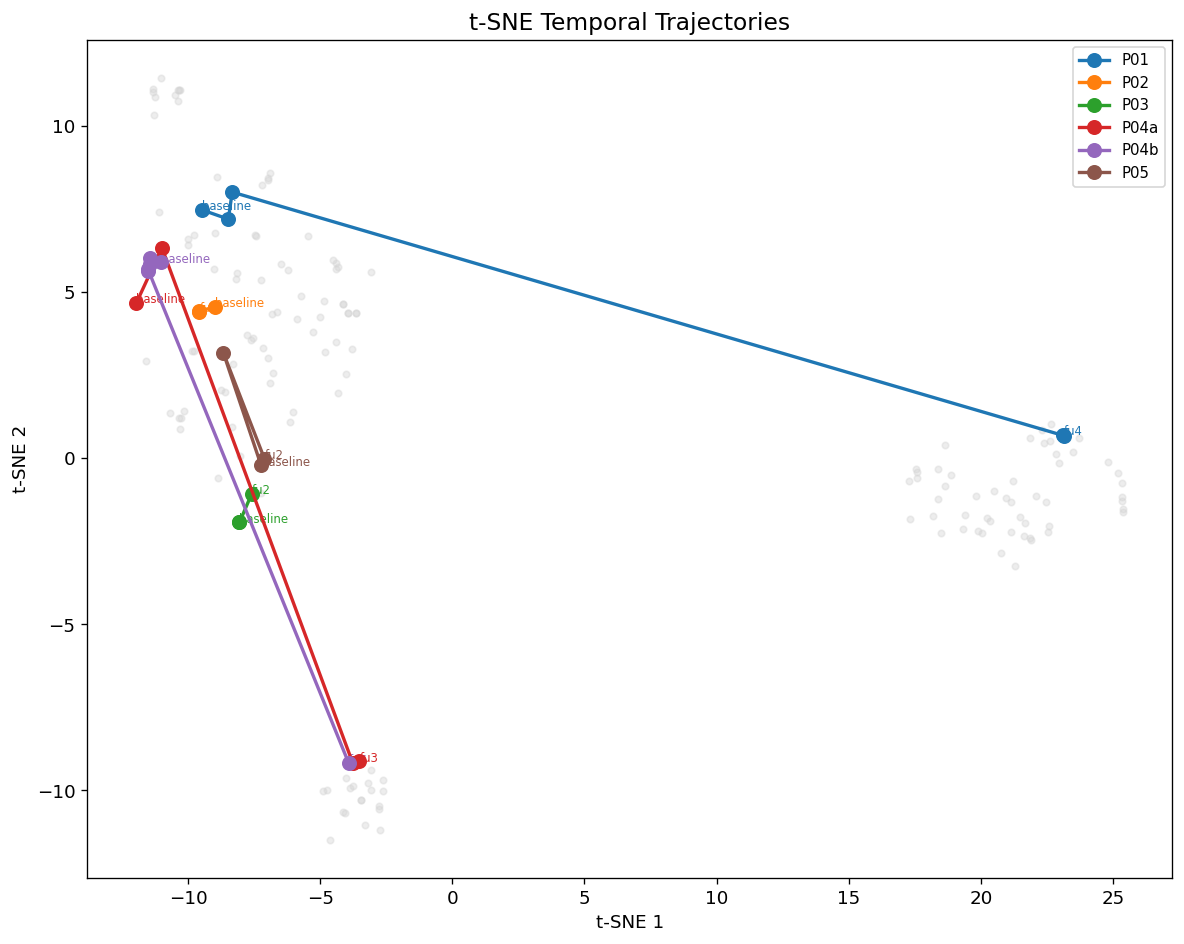

✅ Trajectories: 6 patients


In [12]:
all_keys = sorted(embeddings.keys())
X_all = np.array([embeddings[k] for k in all_keys])
X_sc = StandardScaler().fit_transform(X_all)
tsne = TSNE(n_components=2, perplexity=min(30, len(X_all)-1), random_state=42, max_iter=1000)
X_2d = tsne.fit_transform(X_sc)
key_to_2d = {k: X_2d[i] for i, k in enumerate(all_keys)}

pv = defaultdict(list)
for k in all_keys:
    pid, tp = parse_scan_id(k)
    pv[pid].append((tp, k))
multi = [p for p, v in pv.items() if len(v) >= 3][:6]

fig, ax = plt.subplots(figsize=(10, 8))
ax.scatter(X_2d[:,0], X_2d[:,1], c='lightgray', s=15, alpha=0.4)
cols = plt.cm.tab10(np.linspace(0,1,10))
for ci, pid in enumerate(multi):
    vis = sorted(pv[pid])
    co = np.array([key_to_2d[k] for _,k in vis])
    ax.plot(co[:,0], co[:,1], '-o', color=cols[ci], ms=8, lw=2, label=pid, zorder=5)
    ax.annotate(vis[0][0], co[0], fontsize=7, color=cols[ci])
    ax.annotate(vis[-1][0], co[-1], fontsize=7, color=cols[ci])
ax.legend(fontsize=9); ax.set_title('t-SNE Temporal Trajectories', fontsize=14)
ax.set_xlabel('t-SNE 1'); ax.set_ylabel('t-SNE 2')
plt.tight_layout(); plt.savefig(FIG_DIR/'T2_tsne_trajectories.png', dpi=150); plt.show()
RESULTS['T2_tsne'] = 'saved'
print(f"✅ Trajectories: {len(multi)} patients")

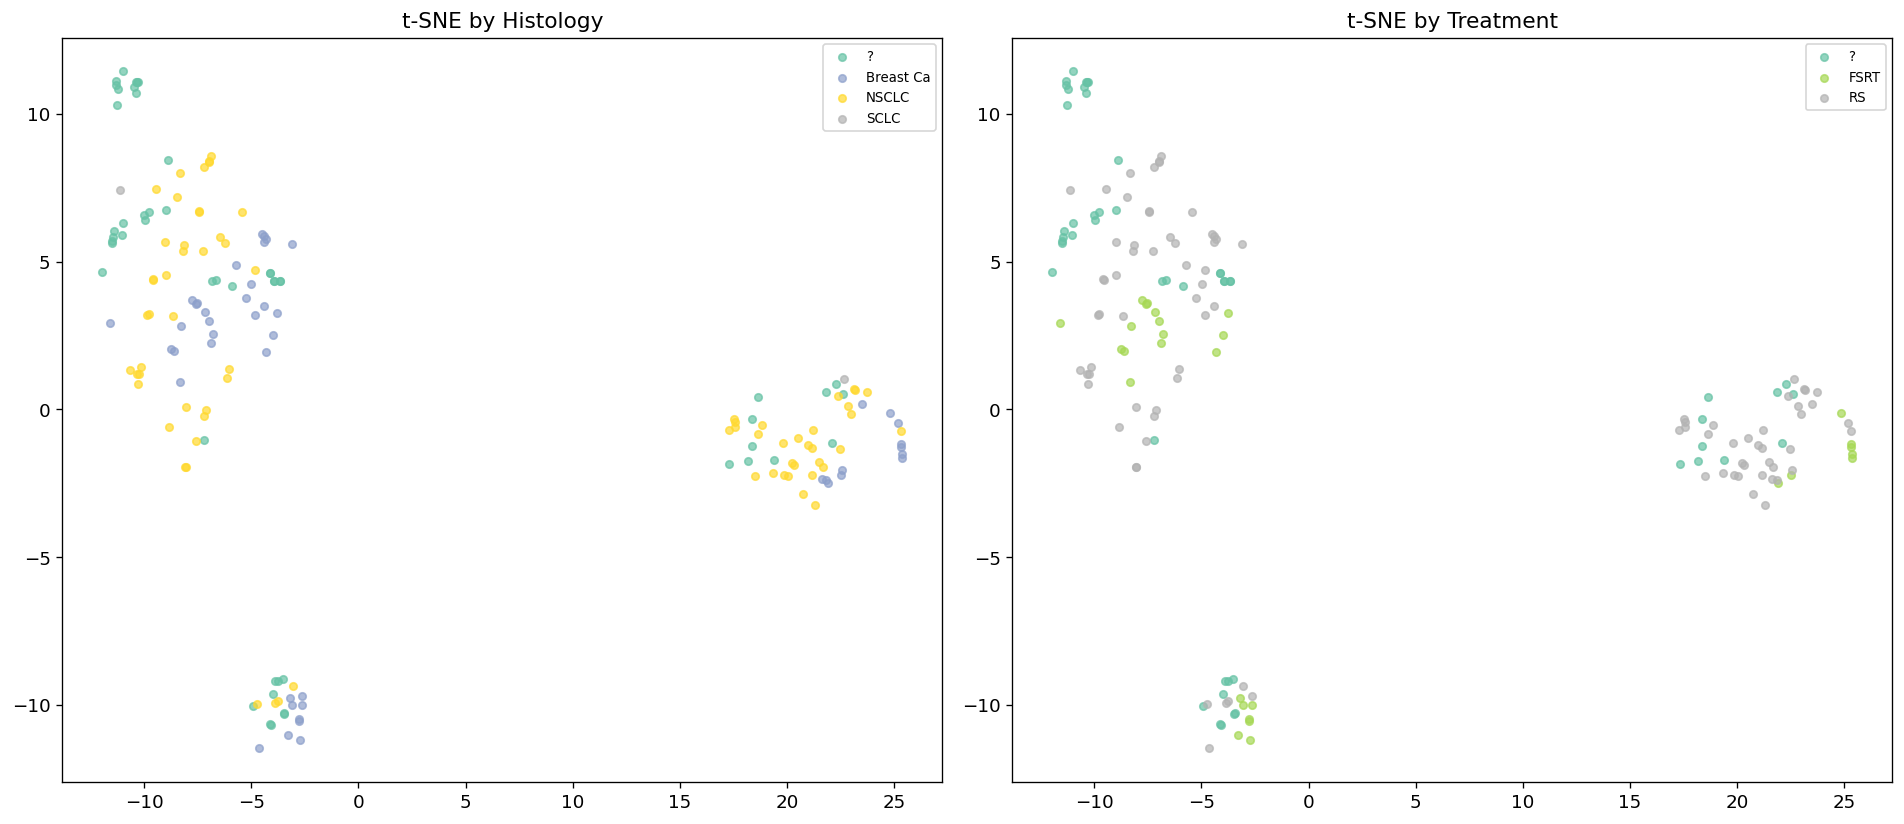

✅ Clinical t-SNE saved


In [13]:
hmap = {r['patient_id']: r.get('Tumour Histology','?') for _,r in clinical.iterrows()}
tmap = {r['patient_id']: r.get('Treatment_Group','?') for _,r in clinical.iterrows()}

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, lm, title in [(axes[0], hmap, 'Histology'), (axes[1], tmap, 'Treatment')]:
    labels = [lm.get(parse_scan_id(k)[0].rstrip('ab'), '?') for k in all_keys]
    uniq = sorted(set(labels))
    cs = plt.cm.Set2(np.linspace(0,1,max(len(uniq),1)))
    for i, u in enumerate(uniq):
        m = np.array([l==u for l in labels])
        ax.scatter(X_2d[m,0], X_2d[m,1], c=[cs[i]], s=20, alpha=0.7, label=u)
    ax.legend(fontsize=8); ax.set_title(f't-SNE by {title}', fontsize=13)
plt.tight_layout(); plt.savefig(FIG_DIR/'tsne_clinical.png', dpi=150); plt.show()
print("✅ Clinical t-SNE saved")

## Step 6: Final Results Summary

In [14]:
thresholds = {
    'M1_volume_R2':('R²',0.1,'Volume prediction'), 'M2_log_volume_R2':('R²',0.1,'Log-volume shape'),
    'M3_svr_R2':('R²',0.05,'Surface-volume ratio'), 'M4_necrosis_F1':('F1',0.5,'Necrosis detection'),
    'M5_elongation_R2':('R²',0.1,'Elongation proxy'), 'M6_nn_consistency_pct':('%',10,'NN consistency'),
    'H1_pca_residual_r':('|r|',0.3,'PCA structure'), 'H2_heterogeneity_R2':('R²',0.1,'Heterogeneity'),
    'H3_subregion_F1':('F1',0.3,'Subregion detect'), 'H4_texture_bundle_R2':('R²',0.05,'Texture bundle'),
    'T1_dist_vol_r':('r',0.05,'Emb dist vs ΔVol'), 'T3_delta_R2':('R²',0.0,'ΔEmb→ΔVol'),
    'T4_response_AUC':('AUC',0.5,'Response pred'), 'T5_coherence_cos':('cos',0.5,'Temporal coherence'),
    'T6_velocity_r':('r',0.05,'Velocity corr'), 'T7_treatment_d':('d',0.1,'Treatment sep'),
}
print("="*72)
print(f"  {'Test':<30} {'Description':<22} {'Metric':>6} {'Value':>8} Pass?")
print("  "+"-"*68)
passed, total = 0, 0
for key, (met, thr, desc) in thresholds.items():
    val = RESULTS.get(key, float('nan'))
    if isinstance(val, (int, float)) and not np.isnan(val):
        ok = val >= thr; passed += int(ok); total += 1
        print(f"  {key:<30} {desc:<22} {met:>6} {val:>8.3f} {'✅' if ok else '❌'}")
    else:
        print(f"  {key:<30} {desc:<22} {met:>6} {'N/A':>8} ⚠️")
print("  "+"-"*68)
print(f"  Score: {passed}/{total} tests passed")
print("="*72)

  Test                           Description            Metric    Value Pass?
  --------------------------------------------------------------------
  M1_volume_R2                   Volume prediction          R²    0.379 ✅
  M2_log_volume_R2               Log-volume shape           R²    0.388 ✅
  M3_svr_R2                      Surface-volume ratio       R²    0.006 ❌
  M4_necrosis_F1                 Necrosis detection         F1    0.707 ✅
  M5_elongation_R2               Elongation proxy           R²    0.387 ✅
  M6_nn_consistency_pct          NN consistency              %   26.790 ✅
  H1_pca_residual_r              PCA structure             |r|    0.796 ✅
  H2_heterogeneity_R2            Heterogeneity              R²    0.386 ✅
  H3_subregion_F1                Subregion detect           F1    0.540 ✅
  H4_texture_bundle_R2           Texture bundle             R²    0.258 ✅
  T1_dist_vol_r                  Emb dist vs ΔVol            r    0.049 ❌
  T3_delta_R2                    ΔEmb

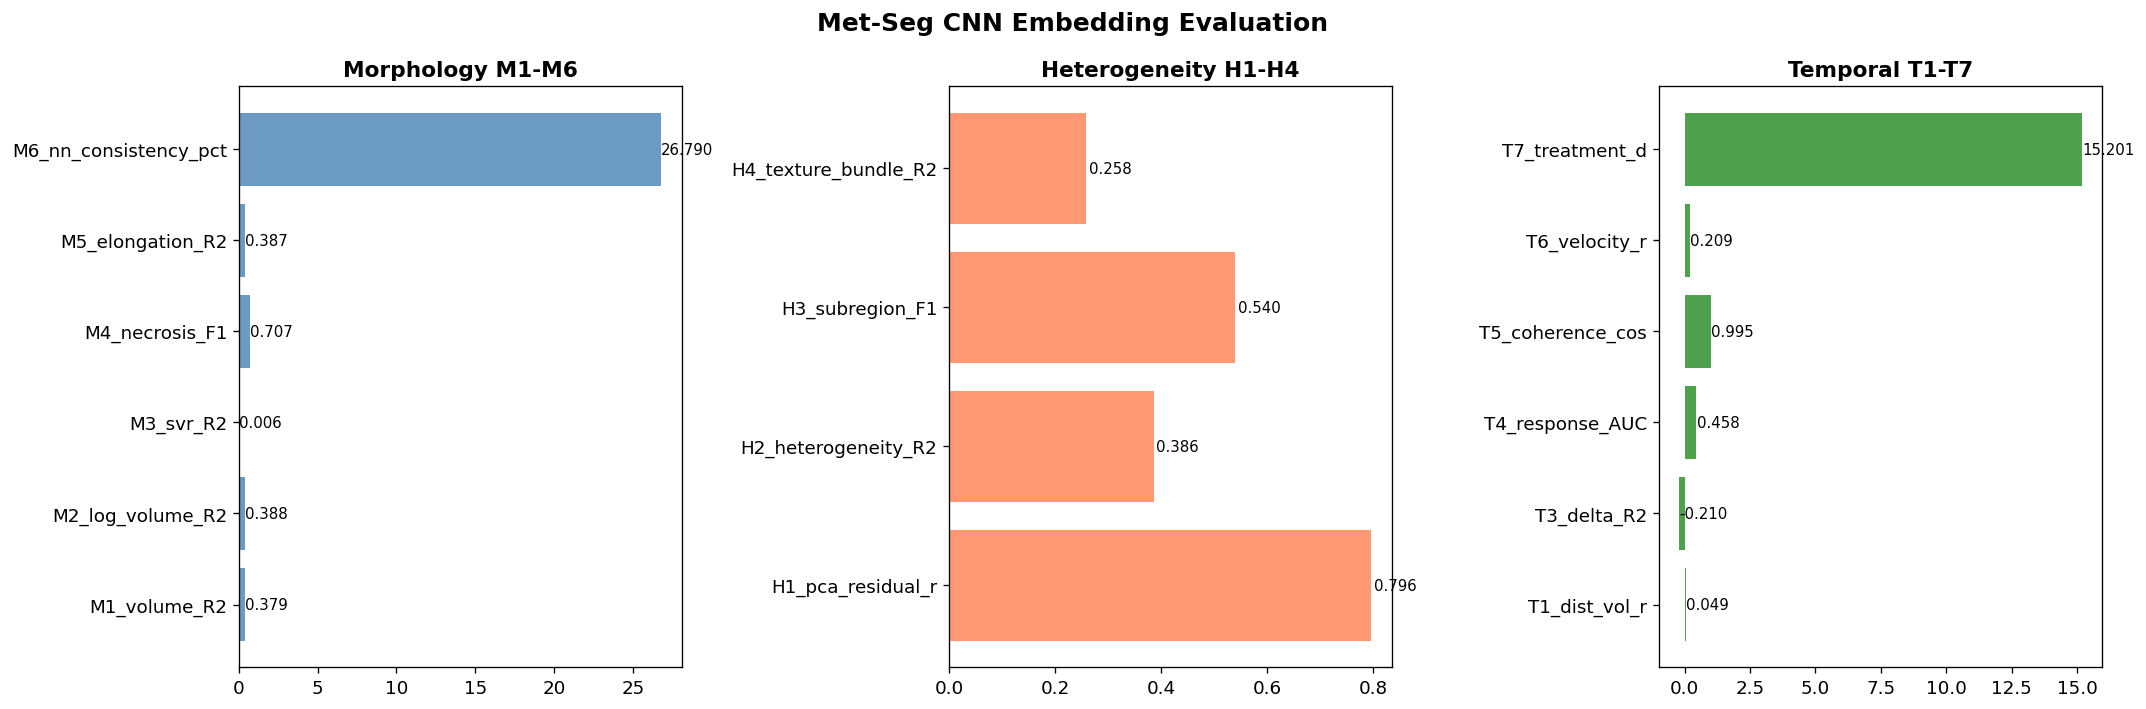

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, (title, pfx, col) in zip(axes, [('Morphology M1-M6','M','steelblue'),
    ('Heterogeneity H1-H4','H','coral'), ('Temporal T1-T7','T','forestgreen')]):
    items = {k:v for k,v in RESULTS.items() if k.startswith(pfx) and isinstance(v,(int,float)) and not np.isnan(v) and k!='T2_tsne'}
    if items:
        bars = ax.barh(list(items.keys()), list(items.values()), color=col, alpha=0.8)
        ax.set_title(title, fontsize=13, fontweight='bold')
        for bar, v in zip(bars, items.values()):
            ax.text(bar.get_width()+0.005, bar.get_y()+bar.get_height()/2, f'{v:.3f}', va='center', fontsize=9)
plt.suptitle('Met-Seg CNN Embedding Evaluation', fontsize=15, fontweight='bold')
plt.tight_layout(); plt.savefig(FIG_DIR/'evaluation_summary.png', dpi=150, bbox_inches='tight'); plt.show()

In [16]:
results_path = OUTPUTS / "activity4_results.json"
ser = {k: float(v) if isinstance(v, (float, np.floating)) else v for k, v in RESULTS.items()}
with open(results_path, 'w') as f:
    json.dump(ser, f, indent=2, default=str)
print(f"\n💾 Results: {results_path}")
print(f"📊 Figures: {FIG_DIR}")
print("\n🏆 Activity 4 COMPLETE!")


💾 Results: /home/moamed/canada_me/explainable_diseas/implementation_cyprus/outputs/activity4_results.json
📊 Figures: /home/moamed/canada_me/explainable_diseas/implementation_cyprus/outputs/activity4_figures

🏆 Activity 4 COMPLETE!
